# Machine Learning for Thermal Engineers
## Lesson 8: Physics-Informed HVAC Cooling Predictor (ML Approach)

Author: Srikantan Natarajan

# 1. Problem Definition

The goal of this notebook is to build a simple machine learning model to predict compressor power for an automotive HVAC system.

We will use:

- physically meaningful features
- feature scaling
- regularization

This model is not meant to represent a production system, but to demonstrate how machine learning can be applied to thermal engineering problems.

# Why This Matters

In automotive HVAC systems, calibrating cooling performance requires:

- extensive wind tunnel testing
- real-world validation drives
- manual tuning of multiple calibration tables

This notebook demonstrates how machine learning can complement traditional approaches by:

- capturing relationships between thermal variables
- reducing calibration complexity
- providing interpretable insights

The goal is not to replace physics-based models, but to augment engineering intuition with data-driven methods.

# 2. Engineering Intuition

Cooling demand in an automotive cabin is driven by:

- Temperature error (CabinTemp − SetTemp)
- Solar radiation (primary contributor during soak)
- Ambient conditions (secondary influence)
- Humidity (minor but non-negligible)

We define:

TempError → baseline cooling demand  
CoolingIndex → solar-amplified cooling demand  

This formulation mirrors real HVAC control strategies where:

- base cooling is governed by temperature deviation
- solar load modulates perceived comfort and system response

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

np.random.seed(42)

In [13]:
n_samples = 300

ambient_temp = np.random.uniform(25, 45, n_samples)
solar_load = np.random.uniform(200, 1000, n_samples)
humidity = np.random.uniform(30, 80, n_samples)
cabin_temp = np.random.uniform(25, 50, n_samples)
set_temp = np.random.uniform(18, 24, n_samples)

noise = np.random.normal(0, 0.3, n_samples)

In [14]:
temp_error = cabin_temp - set_temp
solar_scaled = solar_load / 1000

# Improved physical relationship
compressor_power = (
    0.10 * temp_error
    + 0.20 * temp_error * solar_scaled
    + 0.04 * ambient_temp
    + 0.01 * humidity
    + noise
)

In [15]:
df = pd.DataFrame({
    "AmbientTemp": ambient_temp,
    "SolarLoad": solar_load,
    "Humidity": humidity,
    "CabinTemp": cabin_temp,
    "SetTemp": set_temp,
    "TempError": temp_error,
    "CoolingIndex": temp_error * solar_scaled,
    "CompressorPower": compressor_power
})

df.head()

,AmbientTemp,SolarLoad,Humidity,CabinTemp,SetTemp,TempError,CoolingIndex,CompressorPower
0,32.490802,241.345377,38.446753,30.197156,22.549579,7.647577,1.845707,2.068177
1,44.014286,625.083705,43.929517,25.663305,18.147521,7.515784,4.697994,4.578327
2,39.639879,632.508097,38.850524,29.535886,18.132741,11.403145,7.212581,4.140059
3,36.973170,709.943921,34.435127,39.576039,19.941661,19.634378,13.939307,6.080958
4,28.120373,780.873067,36.031794,35.535614,20.931859,14.603755,11.403679,5.533015


# 3. Feature Selection

We choose features based on engineering understanding:

- TempError → base cooling demand
- CoolingIndex → solar amplification
- AmbientTemp → environmental effect
- Humidity → secondary effect

In [16]:
features = ["TempError", "CoolingIndex", "AmbientTemp", "Humidity"]

X = df[features]
y = df["CompressorPower"]

# 4. Feature Scaling

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Model Training (Ridge Regression)

We use Ridge regression to:

- stabilize coefficients
- handle correlated features

In [18]:
model = Ridge(alpha=1.0)
model.fit(X_scaled, y)

y_pred = model.predict(X_scaled)

print("R2 Score:", round(r2_score(y, y_pred), 4))

R2 Score: 0.9759


# 6. Model Interpretation

In [19]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,TempError,0.725730
1,CoolingIndex,1.301123
2,AmbientTemp,0.243135
3,Humidity,0.135880


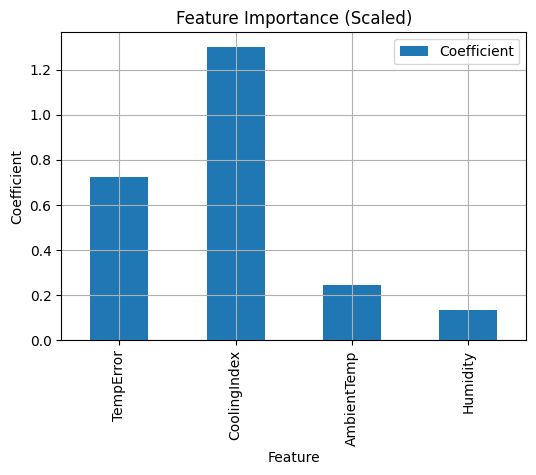

In [20]:
coef_df.set_index("Feature").plot(kind="bar", figsize=(6,4))

plt.title("Feature Importance (Scaled)")
plt.ylabel("Coefficient")

plt.grid(True)
plt.show()

# 7. Visualization

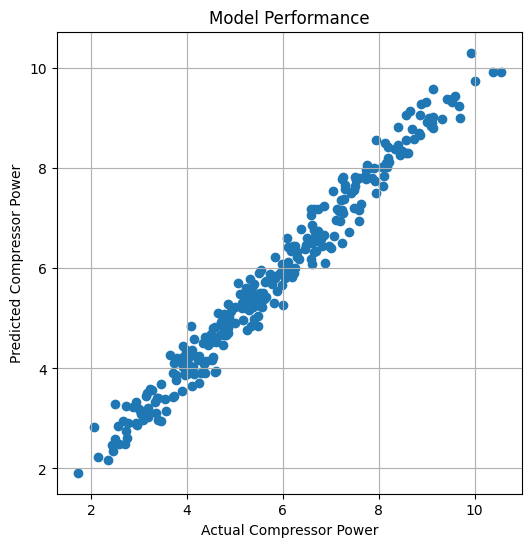

In [21]:
plt.figure(figsize=(6,6))

plt.scatter(y, y_pred)

plt.xlabel("Actual Compressor Power")
plt.ylabel("Predicted Compressor Power")

plt.title("Model Performance")

plt.grid(True)
plt.show()

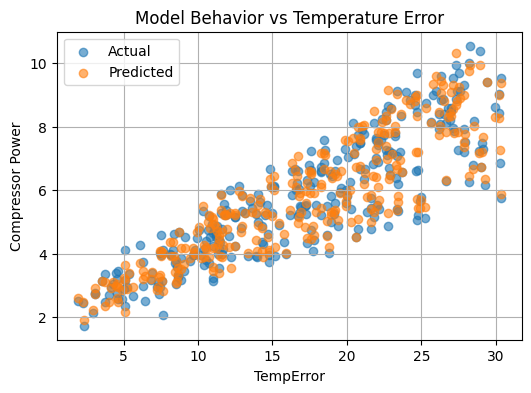

In [22]:
plt.figure(figsize=(6,4))

plt.scatter(df["TempError"], y, label="Actual", alpha=0.6)
plt.scatter(df["TempError"], y_pred, label="Predicted", alpha=0.6)

plt.xlabel("TempError")
plt.ylabel("Compressor Power")
plt.title("Model Behavior vs Temperature Error")

plt.legend()
plt.grid(True)
plt.show()

# 8. Engineering Interpretation of Results

After scaling, the model coefficients represent relative importance.

Key observations:

- CoolingIndex has the strongest influence → solar radiation significantly amplifies cooling demand
- TempError remains a primary driver → baseline cooling requirement
- AmbientTemp contributes moderately → environmental loading
- Humidity plays a smaller role → secondary effect

This suggests that under high solar conditions, cooling demand is driven more by solar amplification effects than temperature error alone.

This aligns with real-world HVAC behavior during solar soak conditions, where radiation significantly impacts perceived and actual thermal load.

# 9. Limitations

- This model uses synthetic data and does not capture full vehicle dynamics
- Cabin thermal mass and time-dependent behavior are not included
- Sensor placement effects (e.g., cabin sensor location) are not modeled
- Real HVAC systems involve control logic and actuator constraints

Future work could include:

- time-series modeling of cooldown behavior
- incorporation of thermal mass effects
- integration with control strategies

# 10. Key Takeaway

Machine learning becomes most powerful when combined with domain knowledge.

Rather than relying on raw variables:

- engineering-informed features (TempError, CoolingIndex)
- improve interpretability
- align with physical intuition
- produce more meaningful models

This approach bridges the gap between physics-based modeling and data-driven methods.